In [1]:
import MotifCompendium


In [1]:
mc = MotifCompendium.load("chrombpnet_outputs/motif_compendium.mc", safe=True)


NameError: name 'MotifCompendium' is not defined

In [2]:
import MotifCompendium.utils.analysis as utils_analysis

utils_analysis.assign_label_from_pfms(
    mc,
    "chrombpnet_outputs/meme_invitro_avg.meme.txt",
    save_col_prefix="chiptf",
    min_score=0.5,
    max_submotifs = 2
)
mc

NameError: name 'mc' is not defined

In [53]:
print(f"Number of composite motifs: {(mc['chiptf_score1'] > 0).sum()}")


Number of composite motifs: 120


In [62]:
# Visualize logos
import MotifCompendium.utils.motif as utils_motif

if "logo (fwd)" not in mc.images():
    mc.add_logos(mc.get_standard_motif_stack(), "logo (fwd)", True)
if "logo (rev)" not in mc.images():
    mc.add_logos(utils_motif.reverse_complement(mc.get_standard_motif_stack()), "logo (rev)", True)

0.5802963962843892
0.881439983844757
Target MC motif: cluster#507


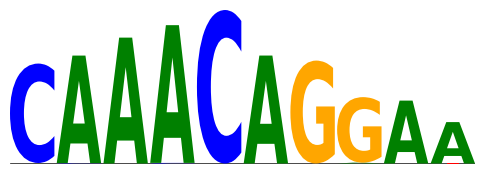

Matched database motif (first): ZNF710_0


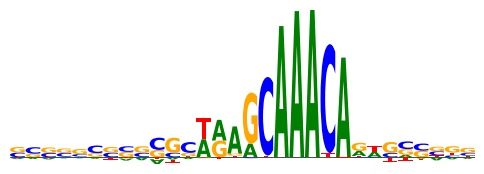

Matched database motif (second): GATA2_4


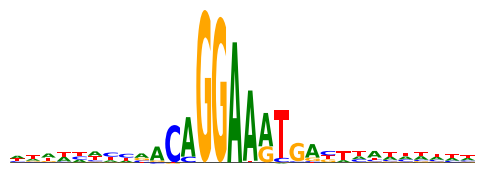

In [63]:
# View example of a matched motif
import base64
from IPython.display import Image, display
annotation_col='chiptf'
mc.sort(by=f"{annotation_col}_score1", ascending=False, inplace=True)
idx=60

print(mc.metadata[f'{annotation_col}_score1'][idx])
print(mc.metadata[f'{annotation_col}_score0'][idx])

logo = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo[idx])
print(f"Target MC motif: {mc.metadata['name'][idx]}")
display(Image(data=image_bytes, format='png'))

match_fwd = mc.get_images(f"{annotation_col}_logo0")
image_bytes = base64.b64decode(match_fwd[idx])
print(f"Matched database motif (first): {mc.metadata[f'{annotation_col}_name0'][idx]}")
display(Image(data=image_bytes, format='png'))

match_fwd = mc.get_images(f"{annotation_col}_logo1")
image_bytes = base64.b64decode(match_fwd[idx])
print(f"Matched database motif (second): {mc.metadata[f'{annotation_col}_name1'][idx]}")
display(Image(data=image_bytes, format='png'))

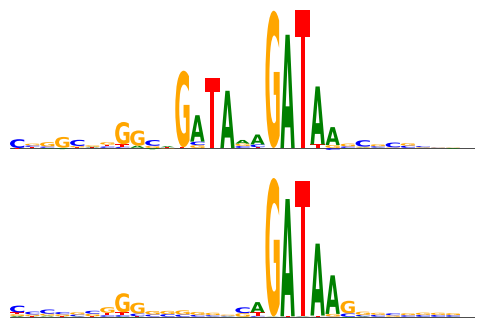

In [34]:
import MotifCompendium.utils.plotting as utils_plotting
%matplotlib inline

utils_plotting.plot_motif_stack(temp.get_standard_motif_stack()[[0, 1]], show=True)

In [33]:
temp = mc[mc["chiptf_name0"]=="GATA1_0"]

In [35]:
temp

,name,source_cluster,num_constituents,motif_string,chiptf_score0,chiptf_name0,chiptf_score1,chiptf_name1
0,cluster#571,571,1,GATA--GATA<br/>TATC--TATC,0.879309,GATA1_0,0.0,
1,cluster#30,30,3,G---------GATAA<br/>TTATC---------C,0.994798,GATA1_0,0.0,


In [36]:
mc_pfm = MotifCompendium.build_from_pfm({"tfchip": "chrombpnet_outputs/meme_invitro_avg.meme.txt"})
mc_pfm

,name,posneg,source
0,tfchip-ARNT2_0,pos,tfchip
1,tfchip-ARNTL_0,pos,tfchip
2,tfchip-ARNT_0,pos,tfchip
3,tfchip-ATF1_0,pos,tfchip
4,tfchip-ATF1_1,pos,tfchip
...,...,...,...
1089,tfchip-ZNF891_0,pos,tfchip
1090,tfchip-ZNF8_0,pos,tfchip
1091,tfchip-ZSCAN25_0,pos,tfchip
1092,tfchip-ZSCAN4_0,pos,tfchip


In [37]:
mc_pfm

,name,posneg,source
0,tfchip-ARNT2_0,pos,tfchip
1,tfchip-ARNTL_0,pos,tfchip
2,tfchip-ARNT_0,pos,tfchip
3,tfchip-ATF1_0,pos,tfchip
4,tfchip-ATF1_1,pos,tfchip
...,...,...,...
1089,tfchip-ZNF891_0,pos,tfchip
1090,tfchip-ZNF8_0,pos,tfchip
1091,tfchip-ZSCAN25_0,pos,tfchip
1092,tfchip-ZSCAN4_0,pos,tfchip


In [38]:
if "logo (fwd)" not in mc_pfm.images():
    mc_pfm.add_logos(mc_pfm.get_standard_motif_stack(), "logo (fwd)", True)


In [39]:
mc_pfm

,name,posneg,source
0,tfchip-ARNT2_0,pos,tfchip
1,tfchip-ARNTL_0,pos,tfchip
2,tfchip-ARNT_0,pos,tfchip
3,tfchip-ATF1_0,pos,tfchip
4,tfchip-ATF1_1,pos,tfchip
...,...,...,...
1089,tfchip-ZNF891_0,pos,tfchip
1090,tfchip-ZNF8_0,pos,tfchip
1091,tfchip-ZSCAN25_0,pos,tfchip
1092,tfchip-ZSCAN4_0,pos,tfchip


In [40]:
temp1 = mc_pfm[mc_pfm["name"]=="tfchip-GATA1_0"]

In [41]:
temp1

,name,posneg,source
0,tfchip-GATA1_0,pos,tfchip


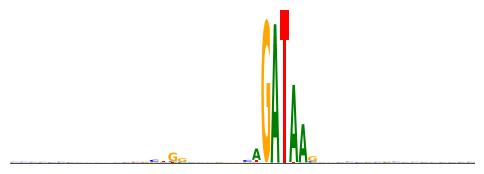

In [43]:
utils_plotting.plot_motif(temp1.get_standard_motif_stack()[0], show=True)

In [64]:
mc[mc['chiptf_name0'] == "GATA1_0"]

,name,source_cluster,num_constituents,motif_string,chiptf_score0,chiptf_name0,chiptf_score1,chiptf_name1
0,cluster#571,571,1,GATA--GATA<br/>TATC--TATC,0.879309,GATA1_0,0.588155,GATAD2B_0
1,cluster#30,30,3,G---------GATAA<br/>TTATC---------C,0.994798,GATA1_0,0.000000,


In [65]:
import MotifCompendium.utils.analysis as utils_analysis

utils_analysis.assign_label_from_pfms(
    mc,
    "chrombpnet_outputs/meme_invitro_avg.meme.txt",
    save_col_prefix="chiptf",
    min_score=0.7,
    max_submotifs = 2
)
mc

,name,source_cluster,num_constituents,motif_string,chiptf_score0,chiptf_name0,chiptf_score1,chiptf_name1
0,cluster#400,400,1,GA-TCA---GGGG--TT<br/>AA--CCCC---TGA-TC,0.703261,RELB_0,0.828280,BATF_0
1,cluster#258,258,1,C-TTGTC-TTGT<br/>ACAA-GACAA-G,0.757799,SOX6_0,0.808030,SOX13_0
2,cluster#156,156,1,GT-ACGT-A-----------CC-A<br/>T-GG-----------T-...,0.000000,,0.000000,
3,cluster#505,505,1,TGACTCA------CCTTGA-C<br/>G-TCAAGG------TGAGTCA,0.782616,ZNF219_2,0.792699,MXI1_2
4,cluster#461,461,1,C---A-C-------C---GCGC<br/>GCGC---G-------G-T---G,0.708707,ZNF518A_0,0.787969,GATA2_5
...,...,...,...,...,...,...,...,...
569,cluster#178,178,1,TGTTTAC<br/>GTAAACA,0.000000,,0.000000,
570,cluster#150,150,1,G--CAAAGT-CA<br/>TG-ACTTTG--C,0.000000,,0.000000,
571,cluster#138,138,1,TGA-TCA<br/>TGA-TCA,0.979796,FOSL2_3,0.000000,
572,cluster#97,97,2,CCC--GGGA<br/>TCCC--GGG,0.993756,EBF1_0,0.000000,


In [66]:
print(f"Number of composite motifs: {(mc['chiptf_score1'] > 0).sum()}")


Number of composite motifs: 12


In [68]:
import MotifCompendium.utils.analysis as utils_analysis

utils_analysis.assign_label_from_pfms(
    mc,
    "chrombpnet_outputs/meme_invitro_avg.meme.txt",
    save_col_prefix="chiptf",
    min_score=0.6,
    max_submotifs = 2
)
mc

,name,source_cluster,num_constituents,motif_string,chiptf_score0,chiptf_name0,chiptf_score1,chiptf_name1
0,cluster#400,400,1,GA-TCA---GGGG--TT<br/>AA--CCCC---TGA-TC,0.703261,RELB_0,0.828280,BATF_0
1,cluster#258,258,1,C-TTGTC-TTGT<br/>ACAA-GACAA-G,0.757799,SOX6_0,0.808030,SOX13_0
2,cluster#156,156,1,GT-ACGT-A-----------CC-A<br/>T-GG-----------T-...,0.664375,PBX1_1,0.807994,XBP1_0
3,cluster#505,505,1,TGACTCA------CCTTGA-C<br/>G-TCAAGG------TGAGTCA,0.782616,ZNF219_2,0.792699,MXI1_2
4,cluster#461,461,1,C---A-C-------C---GCGC<br/>GCGC---G-------G-T---G,0.708707,ZNF518A_0,0.787969,GATA2_5
...,...,...,...,...,...,...,...,...
569,cluster#178,178,1,TGTTTAC<br/>GTAAACA,0.000000,,0.000000,
570,cluster#150,150,1,G--CAAAGT-CA<br/>TG-ACTTTG--C,0.000000,,0.000000,
571,cluster#138,138,1,TGA-TCA<br/>TGA-TCA,0.979796,FOSL2_3,0.000000,
572,cluster#97,97,2,CCC--GGGA<br/>TCCC--GGG,0.993756,EBF1_0,0.000000,


In [69]:
print(f"Number of composite motifs: {(mc['chiptf_score1'] > 0).sum()}")


Number of composite motifs: 49


In [70]:
print(f"Number of composite motifs: {(mc['chiptf_score0'] > 0).sum()}")


Number of composite motifs: 378


In [71]:
utils_analysis.assign_label_from_pfms(
    mc,
    "chrombpnet_outputs/full_database/meme_invitro_metaavg.meme.txt",
    save_col_prefix="ext",
    min_score=0.5,
    max_submotifs = 2
)
mc

,name,source_cluster,num_constituents,motif_string,chiptf_score0,chiptf_name0,chiptf_score1,chiptf_name1,ext_score0,ext_name0,ext_score1,ext_name1
0,cluster#400,400,1,GA-TCA---GGGG--TT<br/>AA--CCCC---TGA-TC,0.703261,RELB_0,0.828280,BATF_0,0.699540,"FOS,RELA,RELB_0",0.801361,"ATF1,ATF2,ATF3,ATF4,BACH1,BATF,BNC2,FOS,FOSL1,..."
1,cluster#258,258,1,C-TTGTC-TTGT<br/>ACAA-GACAA-G,0.757799,SOX6_0,0.808030,SOX13_0,0.755943,"SOX13,SOX5,SOX6_0",0.811722,"SOX13,SOX5,SOX6_0"
2,cluster#156,156,1,GT-ACGT-A-----------CC-A<br/>T-GG-----------T-...,0.664375,PBX1_1,0.807994,XBP1_0,0.639814,SREBF1_0,0.834902,"NFYA,NFYB,NFYC,PBX1_0"
3,cluster#505,505,1,TGACTCA------CCTTGA-C<br/>G-TCAAGG------TGAGTCA,0.782616,ZNF219_2,0.792699,MXI1_2,0.775771,"NR2F6,RXRB,ZNF219,ZNF609_0",0.802047,"ATF1,ATF2,ATF3,ATF4,BACH1,BATF,BNC2,FOS,FOSL1,..."
4,cluster#461,461,1,C---A-C-------C---GCGC<br/>GCGC---G-------G-T---G,0.708707,ZNF518A_0,0.787969,GATA2_5,0.695257,"E2F1,SP1,ZNF224,ZNF230,ZNF391,ZNF501,ZNF510,ZN...",0.653208,"FOXJ3,GATA1,GATA2,GATA3,GATA4,GATAD2B,ZBTB5_0"
...,...,...,...,...,...,...,...,...,...,...,...,...
569,cluster#178,178,1,TGTTTAC<br/>GTAAACA,0.000000,,0.000000,,0.000000,,0.000000,
570,cluster#150,150,1,G--CAAAGT-CA<br/>TG-ACTTTG--C,0.000000,,0.000000,,0.000000,,0.000000,
571,cluster#138,138,1,TGA-TCA<br/>TGA-TCA,0.979796,FOSL2_3,0.000000,,0.962798,"ATF1,ATF2,ATF3,ATF4,BACH1,BATF,BNC2,FOS,FOSL1,...",0.000000,
572,cluster#97,97,2,CCC--GGGA<br/>TCCC--GGG,0.993756,EBF1_0,0.000000,,0.993756,EBF1_0,0.000000,


In [72]:
utils_analysis.assign_label_from_pfms(
    mc,
    "chrombpnet_outputs/meme_invitro_metaavg.meme.txt",
    save_col_prefix="chiptf",
    min_score=0.5,
    max_submotifs = 2
)
mc

FileNotFoundError: File chrombpnet_outputs/meme_invitro_metaavg.meme.txt not found.

In [ ]:
mc.save("chrombpnet_outputs/motif_compendium_labeled.mc")